<a href="https://colab.research.google.com/github/Hartyplaza/AI-Driven-Multi-Output-Prediction-of-Bank-Customer-Loyalty/blob/Master/AI_Driven_Multi_Output_Prediction_of_Bank_Customer_Loyalty_iypnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Driven Multi-Output Prediction of Bank Customer Loyalty
## A Comparative Study with PLS-SEM

**Dataset:** German bank customer survey · n = 675 · 41 variables

**Objective:** Predict multidimensional customer loyalty using ML and compare with PLS-SEM

**Pipeline:**
```
1. Setup & Imports
2. Data Loading & Inspection
3. Preprocessing
4. Exploratory Data Analysis
5. ML Modelling — Multi-Label
6. ML Modelling — Aggregated
7. PLS-SEM Analysis
8. Model Comparison
9. Conclusions
```


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup & Imports

In [ ]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = sns.color_palette('muted')
plt.rcParams['figure.figsize'] = (10, 5)

# ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, roc_auc_score)
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

# Imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# SEM
from sklearn.linear_model import LinearRegression
try:
    from semopy import Model as SemModel
    SEMOPY = True
except ImportError:
    SEMOPY = False
    print('semopy not installed — using OLS path analysis instead')

# SHAP
import shap

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


semopy not installed — using OLS path analysis instead


## 2. Data Loading & Inspection

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/paid projects/DataInBrief_Bankdata.csv')

print('Shape:', df.shape)
print()
print('Columns:', list(df.columns))
print()
df.head()


Shape: (675, 41)

Columns: ['A_1_AGE', 'LOY_1', 'QUAL_1', 'QUAL_2', 'QUAL_4', 'QUAL_5', 'QUAL_6', 'QUA_7', 'PERF_1', 'PERF_2', 'PERF_3', 'PERF_4', 'PERF_5', 'CSOR_1', 'CSOR_2', 'CSOR_3', 'CSOR_4', 'CSOR_5', 'ATTR_1', 'ATTR_2', 'ATTR_3', 'ATTR_4', 'LIKE_1', 'LIKE_2', 'COMP_1', 'COMP_2', 'COMP_3', 'SAT_1', 'SAT_2', 'SAT_3', 'LOY_2', 'LOY_3', 'TRUST_1', 'TRUST_2', 'TRUST_3', 'TRUST_4', 'D_1_GENDER', 'D_2_FAMILY', 'D_3_EDUCATION', 'D_4_EMPLOYMENT', 'D_6_INCOME']



,A_1_AGE,LOY_1,QUAL_1,QUAL_2,QUAL_4,QUAL_5,QUAL_6,QUA_7,PERF_1,PERF_2,...,LOY_3,TRUST_1,TRUST_2,TRUST_3,TRUST_4,D_1_GENDER,D_2_FAMILY,D_3_EDUCATION,D_4_EMPLOYMENT,D_6_INCOME
0,4,7,7,7,7,6,6,6,7,7,...,4,7,7,7,7,1,4,2,3,4
1,5,6,4,4,5,4,4,4,4,4,...,3,4,4,4,4,1,0,6,0,0
2,3,7,7,7,7,7,7,1,7,7,...,7,7,7,7,7,0,4,5,7,4
3,3,7,7,7,7,6,6,4,7,6,...,7,6,6,4,4,1,4,3,7,4
4,2,7,6,6,6,5,6,4,7,7,...,4,7,6,6,6,1,2,6,7,0


In [ ]:
df.describe().round(2)


,A_1_AGE,LOY_1,QUAL_1,QUAL_2,QUAL_4,QUAL_5,QUAL_6,QUA_7,PERF_1,PERF_2,...,LOY_3,TRUST_1,TRUST_2,TRUST_3,TRUST_4,D_1_GENDER,D_2_FAMILY,D_3_EDUCATION,D_4_EMPLOYMENT,D_6_INCOME
count,675.00,675.00,675.00,675.00,675.00,675.00,675.00,675.00,675.00,675.00,...,675.00,675.00,675.00,675.00,675.00,675.00,675.00,675.00,675.00,675.00
mean,4.03,5.94,5.44,5.43,5.81,5.35,5.09,4.71,5.77,5.69,...,4.13,5.49,5.33,4.84,5.08,0.58,3.19,5.06,4.93,2.93
std,1.51,1.42,1.27,1.27,1.21,1.25,1.41,1.35,1.10,1.14,...,1.56,1.30,1.32,1.36,1.36,0.49,1.53,1.66,2.39,1.64
min,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,3.00,5.00,5.00,5.00,5.00,4.00,4.00,4.00,5.00,5.00,...,3.00,5.00,4.00,4.00,4.00,0.00,2.00,3.00,2.00,2.00
50%,4.00,6.00,6.00,6.00,6.00,6.00,5.00,4.00,6.00,6.00,...,4.00,6.00,5.00,5.00,5.00,1.00,4.00,6.00,7.00,3.00
75%,5.00,7.00,6.00,6.00,7.00,6.00,6.00,6.00,7.00,7.00,...,5.00,7.00,6.00,6.00,6.00,1.00,4.00,6.00,7.00,4.00
max,6.00,7.00,7.00,7.00,7.00,7.00,7.00,7.00,7.00,7.00,...,7.00,7.00,7.00,7.00,7.00,1.00,6.00,7.00,7.00,6.00


In [ ]:
# Define construct groups
QUALITY       = ['QUAL_1','QUAL_2','QUAL_4','QUAL_5','QUAL_6','QUA_7']
PERFORMANCE   = ['PERF_1','PERF_2','PERF_3','PERF_4','PERF_5']
CSR           = ['CSOR_1','CSOR_2','CSOR_3','CSOR_4','CSOR_5']
ATTRACTIVENESS= ['ATTR_1','ATTR_2','ATTR_3','ATTR_4']
LIKEABILITY   = ['LIKE_1','LIKE_2']
COMPETENCE    = ['COMP_1','COMP_2','COMP_3']
SATISFACTION  = ['SAT_1','SAT_2','SAT_3']
TRUST         = ['TRUST_1','TRUST_2','TRUST_3','TRUST_4']
LOYALTY       = ['LOY_1','LOY_2','LOY_3']
DEMOGRAPHICS  = ['D_1_GENDER','D_2_FAMILY','D_3_EDUCATION','D_4_EMPLOYMENT','D_6_INCOME']
AGE           = ['A_1_AGE']

CONSTRUCT_MAP = {
    'Quality'       : QUALITY,
    'Performance'   : PERFORMANCE,
    'CSR'           : CSR,
    'Attractiveness': ATTRACTIVENESS,
    'Likeability'   : LIKEABILITY,
    'Competence'    : COMPETENCE,
    'Satisfaction'  : SATISFACTION,
    'Trust'         : TRUST,
    'Loyalty'       : LOYALTY,
}

ALL_PREDICTORS = (QUALITY + PERFORMANCE + CSR + ATTRACTIVENESS +
                  LIKEABILITY + COMPETENCE + SATISFACTION + TRUST +
                  DEMOGRAPHICS + AGE)
ALL_PREDICTORS = list(dict.fromkeys(ALL_PREDICTORS))  # remove duplicates, preserve order

print('Construct summary:')
for name, cols in CONSTRUCT_MAP.items():
    print(f'  {name:<20}: {len(cols)} items')
print(f'\nTotal predictors: {len(ALL_PREDICTORS)}')

# Missing values
print('\nMissing values:')
missing = df.isnull().sum()
print(missing[missing > 0])


Construct summary:
  Quality             : 6 items
  Performance         : 5 items
  CSR                 : 5 items
  Attractiveness      : 4 items
  Likeability         : 2 items
  Competence          : 3 items
  Satisfaction        : 3 items
  Trust               : 4 items
  Loyalty             : 3 items

Total predictors: 38

Missing values:
CSOR_5    3
dtype: int64


## 3. Preprocessing

All variables are already on 1-7 numeric scales.

1. Impute 3 missing values in CSOR_5 with median
2. Bin loyalty items into Low / Neutral / High
3. Train/test split with stratification


In [ ]:
# Median is appropriate for ordinal Likert data — preserves scale integrity
df['CSOR_5'] = df['CSOR_5'].fillna(df['CSOR_5'].median())
print('Missing values after imputation:', df.isnull().sum().sum())


# 1-3 = Low, 4 = Neutral, 5-7 = High
def bin_loyalty(series):
    return pd.cut(series, bins=[0,3,4,7],
                  labels=['Low','Neutral','High'],
                  include_lowest=True)

df['LOY1_class'] = bin_loyalty(df['LOY_1'])
df['LOY2_class'] = bin_loyalty(df['LOY_2'])
df['LOY3_class'] = bin_loyalty(df['LOY_3'])
df['LOY_mean']   = df[LOYALTY].mean(axis=1)
df['LOY_agg_class'] = bin_loyalty(df['LOY_mean'])

print('\nLoyalty class distributions:')
for col in ['LOY1_class','LOY2_class','LOY3_class','LOY_agg_class']:
    counts = df[col].value_counts()
    pcts   = df[col].value_counts(normalize=True).mul(100).round(1)
    print(f'\n  {col}:')
    for cls in ['Low','Neutral','High']:
        print(f'    {cls:<8}: {counts.get(cls,0):>4}  ({pcts.get(cls,0):.1f}%)')


Missing values after imputation: 0

Loyalty class distributions:

  LOY1_class:
    Low     :   39  (5.8%)
    Neutral :   63  (9.3%)
    High    :  573  (84.9%)

  LOY2_class:
    Low     :  112  (16.6%)
    Neutral :  180  (26.7%)
    High    :  383  (56.7%)

  LOY3_class:
    Low     :  193  (28.6%)
    Neutral :  241  (35.7%)
    High    :  241  (35.7%)

  LOY_agg_class:
    Low     :   48  (7.1%)
    Neutral :  104  (15.4%)
    High    :  523  (77.5%)


In [ ]:
# Train/test split
# Stratify on aggregated loyalty class to preserve class distribution
# SMOTE applied inside CV only — never before splitting (prevents leakage)
X = df[ALL_PREDICTORS].values
y_multi = df[['LOY1_class','LOY2_class','LOY3_class']].values
y_agg   = df['LOY_agg_class'].values

X_train, X_test, y_train_m, y_test_m, y_train_agg, y_test_agg = train_test_split(
    X, y_multi, y_agg,
    test_size=0.20, random_state=RANDOM_SEED, stratify=y_agg
)

print(f'Training set : {X_train.shape[0]} rows')
print(f'Test set     : {X_test.shape[0]} rows')
print()
print('Class distribution — aggregated loyalty:')
for split_name, y in [('Train', y_train_agg), ('Test', y_test_agg)]:
    counts = pd.Series(y).value_counts()
    print(f'  {split_name}: Low={counts.get("Low",0)}  Neutral={counts.get("Neutral",0)}  High={counts.get("High",0)}')


Training set : 540 rows
Test set     : 135 rows

Class distribution — aggregated loyalty:
  Train: Low=38  Neutral=83  High=419
  Test: Low=10  Neutral=21  High=104


## 4. Exploratory Data Analysis

### 4.1 Loyalty Variable Distributions

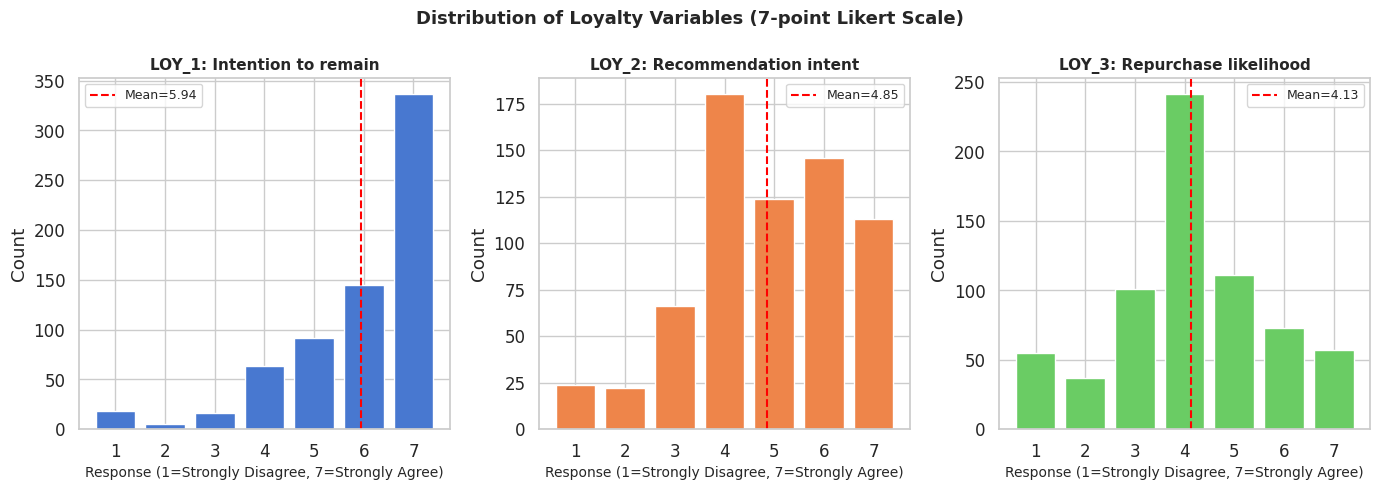

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, (col, title) in enumerate(zip(
    ['LOY_1','LOY_2','LOY_3'],
    ['LOY_1: Intention to remain','LOY_2: Recommendation intent','LOY_3: Repurchase likelihood']
)):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index, counts.values, color=COLORS[i], edgecolor='white')
    axes[i].set_title(title, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Response (1=Strongly Disagree, 7=Strongly Agree)', fontsize=10)
    axes[i].set_ylabel('Count')
    axes[i].set_xticks(range(1,8))
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5,
                    label=f'Mean={mean_val:.2f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribution of Loyalty Variables (7-point Likert Scale)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



### 4.2 Class Imbalance

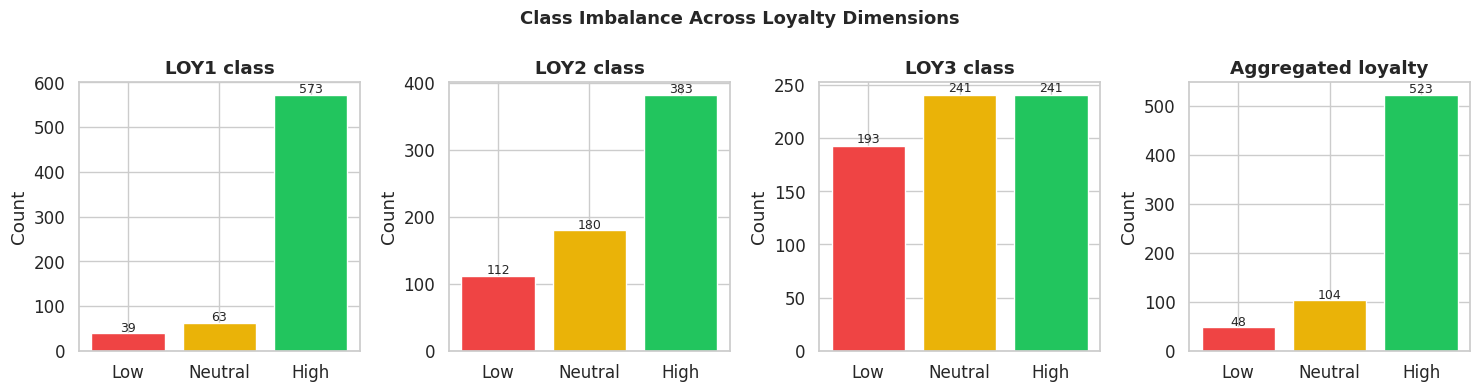

Imbalance ratio (High:Low): 10.9:1


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

class_cols = ['LOY1_class','LOY2_class','LOY3_class','LOY_agg_class']
titles     = ['LOY1 class','LOY2 class','LOY3 class','Aggregated loyalty']
pal        = {'Low':'#ef4444','Neutral':'#eab308','High':'#22c55e'}

for i, (col, title) in enumerate(zip(class_cols, titles)):
    counts = df[col].value_counts().reindex(['Low','Neutral','High'])
    axes[i].bar(counts.index, counts.values,
                color=[pal[c] for c in counts.index], edgecolor='white')
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_ylabel('Count')
    for j, (cls, val) in enumerate(counts.items()):
        axes[i].text(j, val+3, str(val), ha='center', fontsize=9)

plt.suptitle('Class Imbalance Across Loyalty Dimensions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

ratio = df['LOY_agg_class'].value_counts().max() / df['LOY_agg_class'].value_counts().min()
print(f'Imbalance ratio (High:Low): {ratio:.1f}:1')


### 4.3 Construct-Level Correlation Heatmap

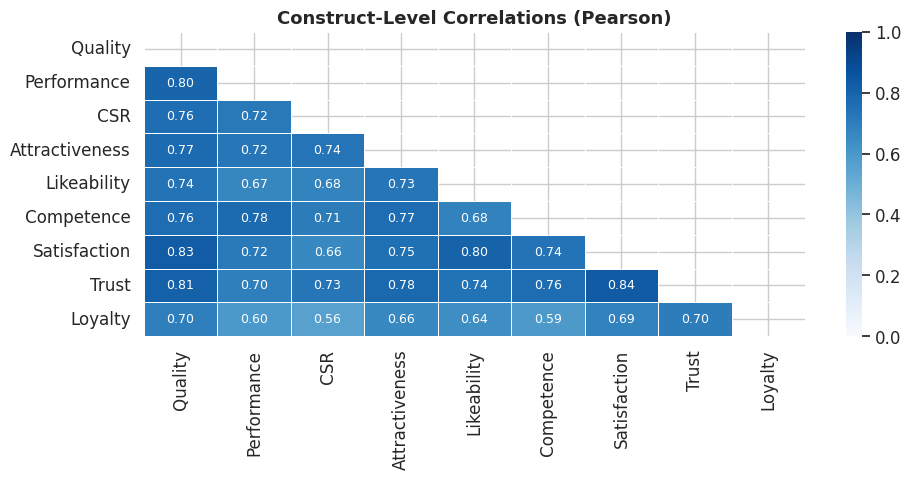

Loyalty correlations with other constructs (sorted):
Trust             0.703
Quality           0.698
Satisfaction      0.686
Attractiveness    0.661
Likeability       0.640
Performance       0.595
Competence        0.591
CSR               0.556


In [ ]:
# Compute construct mean scores
construct_scores = pd.DataFrame({
    name: df[cols].mean(axis=1)
    for name, cols in CONSTRUCT_MAP.items()
})

corr = construct_scores.corr()

fig, ax = plt.subplots(figsize=(10, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size':9})
ax.set_title('Construct-Level Correlations (Pearson)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Loyalty correlations with other constructs (sorted):')
print(corr['Loyalty'].sort_values(ascending=False).drop('Loyalty').round(3).to_string())


### 4.4 Construct Mean Scores — Loyalty vs Non-Loyalty

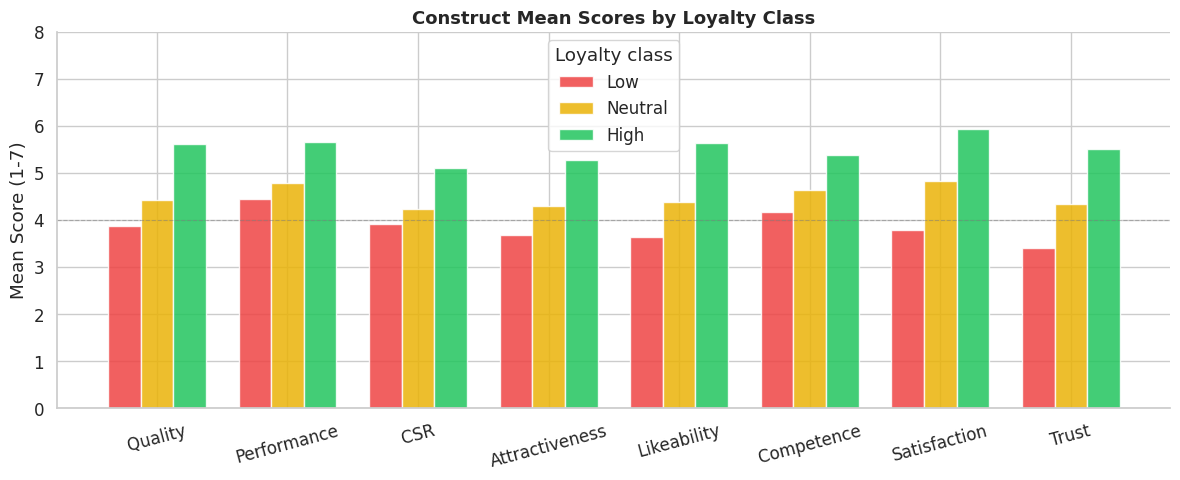

In [ ]:
# Compare construct means between High and Low loyalty groups
construct_scores['LOY_class'] = df['LOY_agg_class'].values

antecedents = ['Quality','Performance','CSR','Attractiveness',
               'Likeability','Competence','Satisfaction','Trust']

means_by_class = construct_scores.groupby('LOY_class')[antecedents].mean()

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(antecedents))
width = 0.25

for i, (cls, color) in enumerate(zip(['Low','Neutral','High'],
                                      ['#ef4444','#eab308','#22c55e'])):
    if cls in means_by_class.index:
        ax.bar(x + i*width, means_by_class.loc[cls, antecedents],
               width, label=cls, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(antecedents, rotation=15)
ax.set_ylabel('Mean Score (1-7)')
ax.set_ylim(0, 8)
ax.set_title('Construct Mean Scores by Loyalty Class', fontsize=13, fontweight='bold')
ax.legend(title='Loyalty class')
ax.axhline(4, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()


### 4.5 Demographic Profile

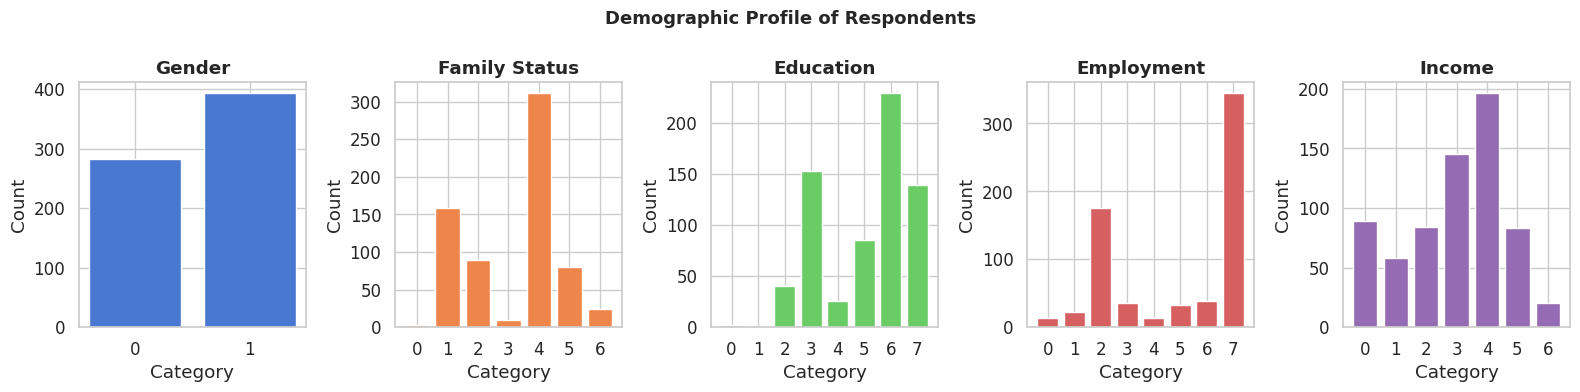

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

demo_labels = {
    'D_1_GENDER'    : 'Gender',
    'D_2_FAMILY'    : 'Family Status',
    'D_3_EDUCATION' : 'Education',
    'D_4_EMPLOYMENT': 'Employment',
    'D_6_INCOME'    : 'Income'
}

for i, (col, label) in enumerate(demo_labels.items()):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values,
                color=COLORS[i], edgecolor='white')
    axes[i].set_title(label, fontweight='bold')
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel('Count')

plt.suptitle('Demographic Profile of Respondents', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. ML Modelling — Multi-Label Classification

Predict LOY1_class, LOY2_class, and LOY3_class simultaneously.

Each model is tested **twice**:
- Without SMOTE: uses `class_weight='balanced'` inside the classifier
- With SMOTE: synthetic minority oversampling applied per output before training

This allows direct comparison of the two imbalance strategies per model.

SMOTE is applied **after** the train/test split — never before (prevents leakage).


In [ ]:
def evaluate_multilabel(y_true, y_pred, model_name):
    """Evaluate multi-label classification across all three loyalty outputs."""
    output_names = ['LOY1_class', 'LOY2_class', 'LOY3_class']
    metrics = []

    print('\n' + '='*60)
    print(f' {model_name}')
    print('='*60)

    for i in range(3):
        acc         = accuracy_score(y_true[:,i], y_pred[:,i])
        f1_macro    = f1_score(y_true[:,i], y_pred[:,i], average='macro', zero_division=0)
        f1_weighted = f1_score(y_true[:,i], y_pred[:,i], average='weighted', zero_division=0)
        print(f'\n  {output_names[i]}:')
        print(f'    Accuracy   : {acc:.4f}')
        print(f'    Macro F1   : {f1_macro:.4f}')
        print(f'    Weighted F1: {f1_weighted:.4f}')
        metrics.append({'acc':acc, 'macro_f1':f1_macro, 'weighted_f1':f1_weighted})

    subset_acc = float(np.mean(np.all(y_true == y_pred, axis=1)))
    avg_acc    = float(np.mean([m['acc'] for m in metrics]))
    avg_f1     = float(np.mean([m['macro_f1'] for m in metrics]))

    print(f'\n  Subset accuracy (exact match): {subset_acc:.4f}')
    print(f'  Average accuracy             : {avg_acc:.4f}')
    print(f'  Average macro F1             : {avg_f1:.4f}')

    return {'model':model_name, 'subset_acc':subset_acc,
            'avg_acc':avg_acc, 'avg_macro_f1':avg_f1}

ml_results = []
smote = SMOTE(random_state=RANDOM_SEED)


### 5.1 Baseline

In [ ]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
dummy.fit(X_train, y_train_agg)
y_pred_dummy = dummy.predict(X_test)

dummy_acc = accuracy_score(y_test_agg, y_pred_dummy)
dummy_f1  = f1_score(y_test_agg, y_pred_dummy, average='macro', zero_division=0)

print('Baseline (most frequent class):')
print(f'  Accuracy : {dummy_acc:.4f}')
print(f'  Macro F1 : {dummy_f1:.4f}')
print(f'  Always predicts: High — zero ability to detect Low or Neutral loyalty')


Baseline (most frequent class):
  Accuracy : 0.7704
  Macro F1 : 0.2901
  Always predicts: High — zero ability to detect Low or Neutral loyalty


### 5.2 Random Forest

In [ ]:
# Without SMOTE — uses class_weight='balanced'
rf_base = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_split=5,
    class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1
)
rf_ml = MultiOutputClassifier(rf_base)
rf_ml.fit(X_train, y_train_m)
y_pred_rf = rf_ml.predict(X_test)

rf_res = evaluate_multilabel(y_test_m, y_pred_rf, 'Random Forest (no SMOTE)')
ml_results.append(rf_res)



 Random Forest (no SMOTE)

  LOY1_class:
    Accuracy   : 0.8296
    Macro F1   : 0.4692
    Weighted F1: 0.7870

  LOY2_class:
    Accuracy   : 0.6741
    Macro F1   : 0.5639
    Weighted F1: 0.6608

  LOY3_class:
    Accuracy   : 0.4889
    Macro F1   : 0.4801
    Weighted F1: 0.4894

  Subset accuracy (exact match): 0.3037
  Average accuracy             : 0.6642
  Average macro F1             : 0.5044


In [ ]:
# With SMOTE — applied per output, no class_weight needed
rf_smote_preds = []
for i in range(3):
    X_res, y_res = smote.fit_resample(X_train, y_train_m[:, i])
    rf_i = RandomForestClassifier(
        n_estimators=300, max_depth=15, min_samples_split=5,
        random_state=RANDOM_SEED, n_jobs=-1
    )
    rf_i.fit(X_res, y_res)
    rf_smote_preds.append(rf_i.predict(X_test))

y_pred_rf_smote = np.column_stack(rf_smote_preds)
rf_smote_res = evaluate_multilabel(y_test_m, y_pred_rf_smote, 'Random Forest + SMOTE')
ml_results.append(rf_smote_res)



 Random Forest + SMOTE

  LOY1_class:
    Accuracy   : 0.8148
    Macro F1   : 0.4911
    Weighted F1: 0.7864

  LOY2_class:
    Accuracy   : 0.6741
    Macro F1   : 0.5612
    Weighted F1: 0.6590

  LOY3_class:
    Accuracy   : 0.4963
    Macro F1   : 0.4858
    Weighted F1: 0.4982

  Subset accuracy (exact match): 0.3111
  Average accuracy             : 0.6617
  Average macro F1             : 0.5127


### 5.3 XGBoost

In [ ]:
# Without SMOTE — uses scale_pos_weight per output
le_dict_xgb = {}
xgb_preds = []

for i in range(3):
    le = LabelEncoder()
    y_enc = le.fit_transform(y_train_m[:, i])
    le_dict_xgb[i] = le

    xgb_i = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        eval_metric='mlogloss', random_state=RANDOM_SEED,
        use_label_encoder=False, n_jobs=-1, verbosity=0
    )
    xgb_i.fit(X_train, y_enc)
    xgb_preds.append(le.inverse_transform(xgb_i.predict(X_test)))

y_pred_xgb = np.column_stack(xgb_preds)
xgb_res = evaluate_multilabel(y_test_m, y_pred_xgb, 'XGBoost (no SMOTE)')
ml_results.append(xgb_res)



 XGBoost (no SMOTE)

  LOY1_class:
    Accuracy   : 0.8296
    Macro F1   : 0.5060
    Weighted F1: 0.7970

  LOY2_class:
    Accuracy   : 0.6741
    Macro F1   : 0.5907
    Weighted F1: 0.6714

  LOY3_class:
    Accuracy   : 0.5037
    Macro F1   : 0.5020
    Weighted F1: 0.5078

  Subset accuracy (exact match): 0.3037
  Average accuracy             : 0.6691
  Average macro F1             : 0.5329


In [ ]:
# With SMOTE — applied per output
le_dict_xgb_s = {}
xgb_smote_preds = []

for i in range(3):
    le = LabelEncoder()
    y_enc = le.fit_transform(y_train_m[:, i])
    le_dict_xgb_s[i] = le

    X_res, y_res = smote.fit_resample(X_train, y_enc)

    xgb_i = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        eval_metric='mlogloss', random_state=RANDOM_SEED,
        use_label_encoder=False, n_jobs=-1, verbosity=0
    )
    xgb_i.fit(X_res, y_res)
    xgb_smote_preds.append(le.inverse_transform(xgb_i.predict(X_test)))

y_pred_xgb_smote = np.column_stack(xgb_smote_preds)
xgb_smote_res = evaluate_multilabel(y_test_m, y_pred_xgb_smote, 'XGBoost + SMOTE')
ml_results.append(xgb_smote_res)



 XGBoost + SMOTE

  LOY1_class:
    Accuracy   : 0.8370
    Macro F1   : 0.5382
    Weighted F1: 0.8119

  LOY2_class:
    Accuracy   : 0.6519
    Macro F1   : 0.5576
    Weighted F1: 0.6465

  LOY3_class:
    Accuracy   : 0.5333
    Macro F1   : 0.5220
    Weighted F1: 0.5355

  Subset accuracy (exact match): 0.3037
  Average accuracy             : 0.6741
  Average macro F1             : 0.5393


### 5.4 MLP Neural Network

In [ ]:
# Without SMOTE
le_dict_mlp = {}
mlp_preds = []

for i in range(3):
    le = LabelEncoder()
    y_enc = le.fit_transform(y_train_m[:, i])
    le_dict_mlp[i] = le

    mlp_i = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32), activation='relu',
        solver='adam', max_iter=500, random_state=RANDOM_SEED,
        early_stopping=True, validation_fraction=0.1
    )
    mlp_i.fit(X_train, y_enc)
    mlp_preds.append(le.inverse_transform(mlp_i.predict(X_test)))

y_pred_mlp = np.column_stack(mlp_preds)
mlp_res = evaluate_multilabel(y_test_m, y_pred_mlp, 'MLP (no SMOTE)')
ml_results.append(mlp_res)



 MLP (no SMOTE)

  LOY1_class:
    Accuracy   : 0.8222
    Macro F1   : 0.3008
    Weighted F1: 0.7420

  LOY2_class:
    Accuracy   : 0.6444
    Macro F1   : 0.5150
    Weighted F1: 0.6084

  LOY3_class:
    Accuracy   : 0.5111
    Macro F1   : 0.5096
    Weighted F1: 0.5125

  Subset accuracy (exact match): 0.2741
  Average accuracy             : 0.6593
  Average macro F1             : 0.4418


In [ ]:
# With SMOTE
le_dict_mlp_s = {}
mlp_smote_preds = []

for i in range(3):
    le = LabelEncoder()
    y_enc = le.fit_transform(y_train_m[:, i])
    le_dict_mlp_s[i] = le

    X_res, y_res = smote.fit_resample(X_train, y_enc)

    mlp_i = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32), activation='relu',
        solver='adam', max_iter=500, random_state=RANDOM_SEED,
        early_stopping=True, validation_fraction=0.1
    )
    mlp_i.fit(X_res, y_res)
    mlp_smote_preds.append(le.inverse_transform(mlp_i.predict(X_test)))

y_pred_mlp_smote = np.column_stack(mlp_smote_preds)
mlp_smote_res = evaluate_multilabel(y_test_m, y_pred_mlp_smote, 'MLP + SMOTE')
ml_results.append(mlp_smote_res)



 MLP + SMOTE

  LOY1_class:
    Accuracy   : 0.7185
    Macro F1   : 0.4086
    Weighted F1: 0.7363

  LOY2_class:
    Accuracy   : 0.5778
    Macro F1   : 0.5333
    Weighted F1: 0.5874

  LOY3_class:
    Accuracy   : 0.5037
    Macro F1   : 0.4907
    Weighted F1: 0.4932

  Subset accuracy (exact match): 0.2444
  Average accuracy             : 0.6000
  Average macro F1             : 0.4776


### 5.5 Multi-Label Results Summary

Multi-Label Model Comparison:
                   model  avg_acc  avg_macro_f1  subset_acc
Random Forest (no SMOTE) 0.664198      0.504415    0.303704
   Random Forest + SMOTE 0.661728      0.512716    0.311111
      XGBoost (no SMOTE) 0.669136      0.532878    0.303704
         XGBoost + SMOTE 0.674074      0.539260    0.303704
          MLP (no SMOTE) 0.659259      0.441787    0.274074
             MLP + SMOTE 0.600000      0.477566    0.244444


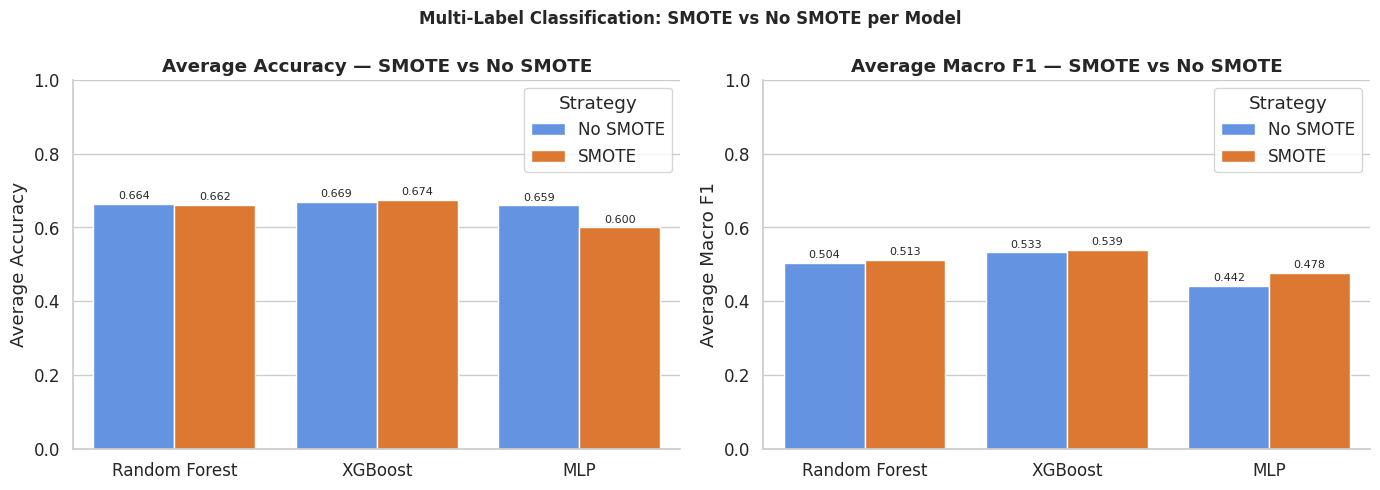


SMOTE impact summary:
  Random Forest  : Accuracy -0.0025  |  Macro F1 +0.0083
  XGBoost        : Accuracy +0.0049  |  Macro F1 +0.0064
  MLP            : Accuracy -0.0593  |  Macro F1 +0.0358


In [ ]:
ml_df = pd.DataFrame(ml_results)
print('Multi-Label Model Comparison:')
print(ml_df[['model','avg_acc','avg_macro_f1','subset_acc']].to_string(index=False))

# Manually assign base model and version labels
base_map = {
    'Random Forest (no SMOTE)' : 'Random Forest',
    'Random Forest + SMOTE'    : 'Random Forest',
    'XGBoost (no SMOTE)'       : 'XGBoost',
    'XGBoost + SMOTE'          : 'XGBoost',
    'MLP (no SMOTE)'           : 'MLP',
    'MLP + SMOTE'              : 'MLP',
}
ver_map = {
    'Random Forest (no SMOTE)' : 'No SMOTE',
    'Random Forest + SMOTE'    : 'SMOTE',
    'XGBoost (no SMOTE)'       : 'No SMOTE',
    'XGBoost + SMOTE'          : 'SMOTE',
    'MLP (no SMOTE)'           : 'No SMOTE',
    'MLP + SMOTE'              : 'SMOTE',
}
ml_df['Base']    = ml_df['model'].map(base_map)
ml_df['Version'] = ml_df['model'].map(ver_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {'No SMOTE': '#4f8ef7', 'SMOTE': '#f97316'}

sns.barplot(data=ml_df, x='Base', y='avg_acc',
            hue='Version', palette=palette, ax=axes[0])
axes[0].set_title('Average Accuracy — SMOTE vs No SMOTE', fontweight='bold')
axes[0].set_ylabel('Average Accuracy')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 1.0)
axes[0].legend(title='Strategy')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', fontsize=8, padding=2)

sns.barplot(data=ml_df, x='Base', y='avg_macro_f1',
            hue='Version', palette=palette, ax=axes[1])
axes[1].set_title('Average Macro F1 — SMOTE vs No SMOTE', fontweight='bold')
axes[1].set_ylabel('Average Macro F1')
axes[1].set_xlabel('')
axes[1].set_ylim(0, 1.0)
axes[1].legend(title='Strategy')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.3f', fontsize=8, padding=2)

sns.despine()
plt.suptitle('Multi-Label Classification: SMOTE vs No SMOTE per Model',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nSMOTE impact summary:')
for base in ['Random Forest','XGBoost','MLP']:
    sub = ml_df[ml_df['Base']==base].set_index('Version')
    if 'No SMOTE' in sub.index and 'SMOTE' in sub.index:
        acc_diff = sub.loc['SMOTE','avg_acc'] - sub.loc['No SMOTE','avg_acc']
        f1_diff  = sub.loc['SMOTE','avg_macro_f1'] - sub.loc['No SMOTE','avg_macro_f1']
        print(f'  {base:<15}: Accuracy {acc_diff:+.4f}  |  Macro F1 {f1_diff:+.4f}')


## 6. ML Modelling — Aggregated Classification

Predict a single aggregated loyalty class (mean of LOY_1, LOY_2, LOY_3 binned).

All models use **SMOTE** applied after the train/test split.
Each model includes: classification report · confusion matrix · feature importance (where available)


In [ ]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred, labels=['Low','Neutral','High'])
    cm_df = pd.DataFrame(cm,
        index=['True Low','True Neutral','True High'],
        columns=['Pred Low','Pred Neutral','Pred High'])
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues',
                linewidths=0.5, ax=ax)
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_feature_importance(importances, feature_names, model_name, top_n=10):
    imp_df = pd.DataFrame({'Feature':feature_names, 'Importance':importances})
    imp_df = imp_df.sort_values('Importance', ascending=True).tail(top_n)
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(imp_df['Feature'], imp_df['Importance'],
            color=COLORS[0], edgecolor='white')
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top {top_n} Feature Importances — {model_name}', fontweight='bold')
    sns.despine()
    plt.tight_layout()
    plt.show()
    print(f'Top 10 features ({model_name}):')
    print(imp_df.sort_values('Importance', ascending=False).head(10).to_string(index=False))

def evaluate_aggregated(y_true, y_pred, model_name, model=None):
    acc         = accuracy_score(y_true, y_pred)
    f1_macro    = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print('\n' + '='*55)
    print(f' {model_name}')
    print('='*55)
    print(f'  Accuracy   : {acc:.4f}')
    print(f'  Macro F1   : {f1_macro:.4f}')
    print(f'  Weighted F1: {f1_weighted:.4f}')
    print()
    print(classification_report(y_true, y_pred, zero_division=0))
    roc = None
    if model is not None and hasattr(model, 'predict_proba'):
        try:
            y_bin   = label_binarize(y_true, classes=['Low','Neutral','High'])
            y_score = model.predict_proba(X_test)
            roc = roc_auc_score(y_bin, y_score, average='macro', multi_class='ovr')
            print(f'  ROC-AUC (macro OvR): {roc:.4f}')
        except Exception as e:
            print(f'  ROC-AUC: could not compute ({e})')
    return {'model':model_name, 'accuracy':acc,
            'macro_f1':f1_macro, 'weighted_f1':f1_weighted, 'roc_auc':roc}

agg_results = []
smote = SMOTE(random_state=RANDOM_SEED)


### 6.1 Baseline

Baseline (most frequent class):
  Accuracy : 0.7704
  Macro F1 : 0.2901
  Always predicts High — Macro F1 near 0



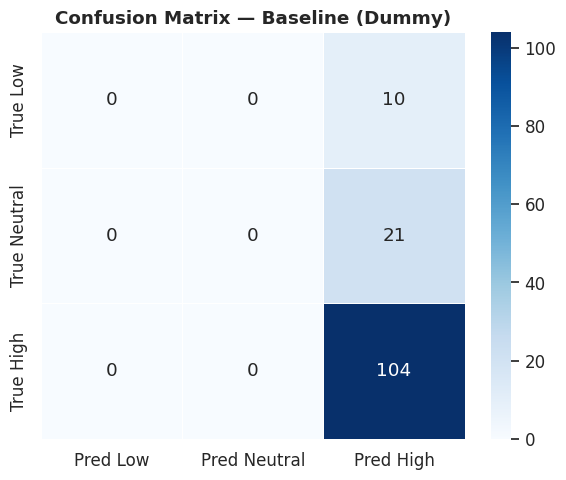

In [ ]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
dummy.fit(X_train, y_train_agg)
y_pred_dummy = dummy.predict(X_test)

dummy_acc = accuracy_score(y_test_agg, y_pred_dummy)
dummy_f1  = f1_score(y_test_agg, y_pred_dummy, average='macro', zero_division=0)

print('Baseline (most frequent class):')
print(f'  Accuracy : {dummy_acc:.4f}')
print(f'  Macro F1 : {dummy_f1:.4f}')
print('  Always predicts High — Macro F1 near 0')
print()
plot_confusion_matrix(y_test_agg, y_pred_dummy, 'Baseline (Dummy)')


### 6.2 Random Forest + SMOTE


 Random Forest + SMOTE
  Accuracy   : 0.7556
  Macro F1   : 0.5321
  Weighted F1: 0.7443

              precision    recall  f1-score   support

        High       0.85      0.89      0.87       104
         Low       0.57      0.40      0.47        10
     Neutral       0.28      0.24      0.26        21

    accuracy                           0.76       135
   macro avg       0.56      0.51      0.53       135
weighted avg       0.74      0.76      0.74       135

  ROC-AUC (macro OvR): 0.3850


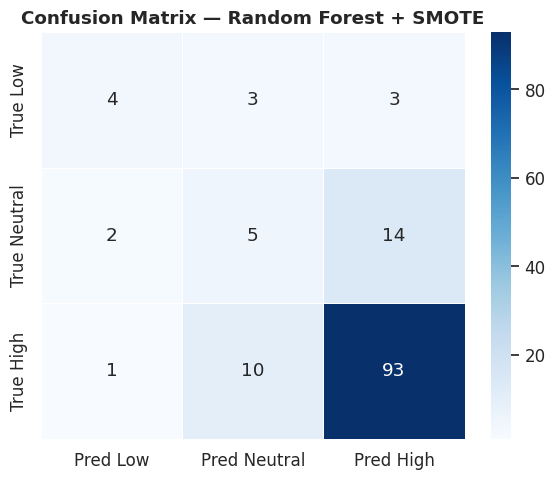

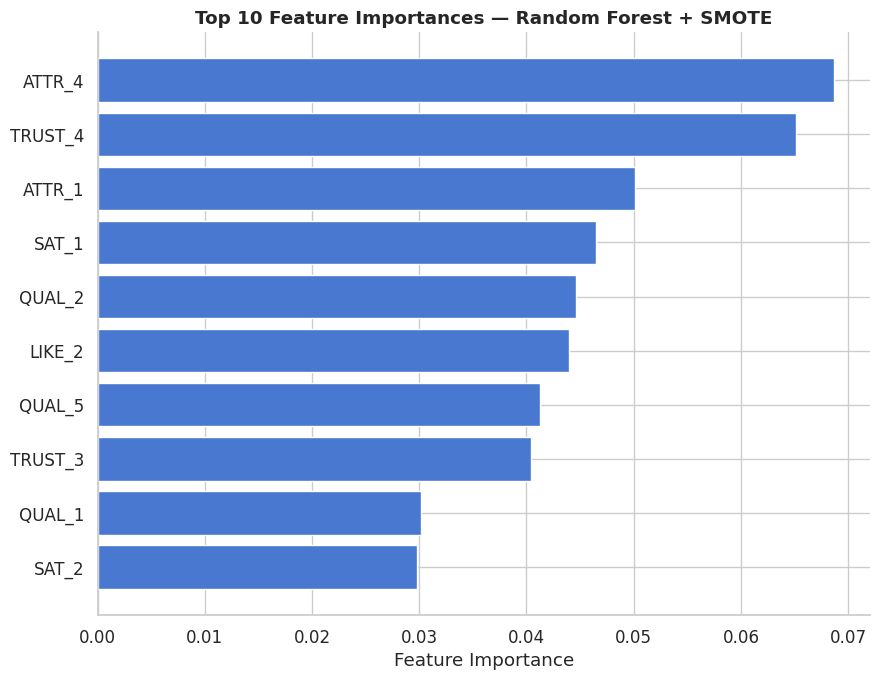

Top 10 features (Random Forest + SMOTE):
Feature  Importance
 ATTR_4    0.068646
TRUST_4    0.065156
 ATTR_1    0.050100
  SAT_1    0.046500
 QUAL_2    0.044593
 LIKE_2    0.044005
 QUAL_5    0.041298
TRUST_3    0.040470
 QUAL_1    0.030179
  SAT_2    0.029793


In [ ]:
X_train_rf, y_train_rf = smote.fit_resample(X_train, y_train_agg)

rf_agg = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_split=5,
    random_state=RANDOM_SEED, n_jobs=-1
)
rf_agg.fit(X_train_rf, y_train_rf)
y_pred_rf_agg = rf_agg.predict(X_test)

rf_agg_res = evaluate_aggregated(
    y_test_agg, y_pred_rf_agg, 'Random Forest + SMOTE', rf_agg)
agg_results.append(rf_agg_res)

plot_confusion_matrix(y_test_agg, y_pred_rf_agg, 'Random Forest + SMOTE')
plot_feature_importance(rf_agg.feature_importances_, ALL_PREDICTORS,
                        'Random Forest + SMOTE')


### 6.3 XGBoost + SMOTE


 XGBoost + SMOTE
  Accuracy   : 0.7556
  Macro F1   : 0.5545
  Weighted F1: 0.7442

              precision    recall  f1-score   support

        High       0.83      0.88      0.86       104
         Low       0.67      0.40      0.50        10
     Neutral       0.33      0.29      0.31        21

    accuracy                           0.76       135
   macro avg       0.61      0.52      0.55       135
weighted avg       0.74      0.76      0.74       135

  ROC-AUC (macro OvR): 0.4045


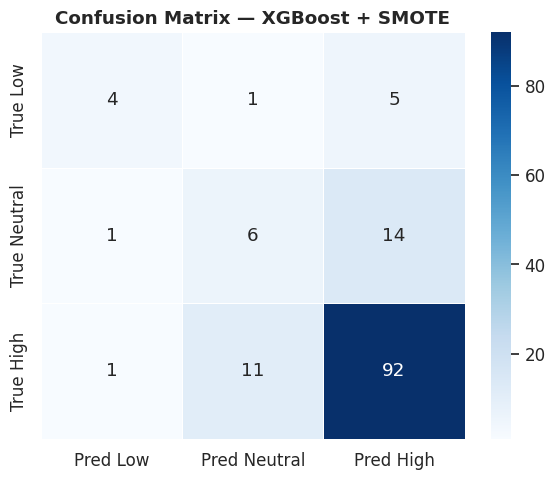

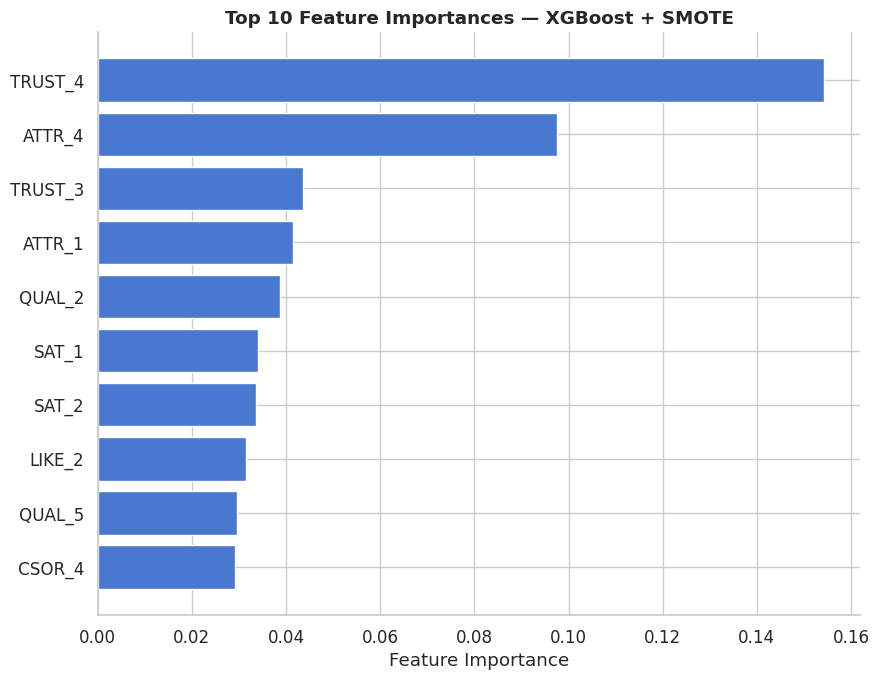

Top 10 features (XGBoost + SMOTE):
Feature  Importance
TRUST_4    0.154270
 ATTR_4    0.097568
TRUST_3    0.043696
 ATTR_1    0.041428
 QUAL_2    0.038827
  SAT_1    0.034143
  SAT_2    0.033566
 LIKE_2    0.031431
 QUAL_5    0.029599
 CSOR_4    0.029226


In [ ]:
le_agg = LabelEncoder()
y_train_agg_enc = le_agg.fit_transform(y_train_agg)

X_train_xgb, y_train_xgb = smote.fit_resample(X_train, y_train_agg_enc)

xgb_agg = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    eval_metric='mlogloss', random_state=RANDOM_SEED,
    use_label_encoder=False, n_jobs=-1, verbosity=0
)
xgb_agg.fit(X_train_xgb, y_train_xgb)
y_pred_xgb_agg = le_agg.inverse_transform(xgb_agg.predict(X_test))

class XGBWrapper:
    def predict_proba(self, X):
        return xgb_agg.predict_proba(X)

xgb_agg_res = evaluate_aggregated(
    y_test_agg, y_pred_xgb_agg, 'XGBoost + SMOTE', XGBWrapper())
agg_results.append(xgb_agg_res)

plot_confusion_matrix(y_test_agg, y_pred_xgb_agg, 'XGBoost + SMOTE')
plot_feature_importance(xgb_agg.feature_importances_, ALL_PREDICTORS,
                        'XGBoost + SMOTE')


### 6.4 MLP + SMOTE


 MLP + SMOTE
  Accuracy   : 0.6667
  Macro F1   : 0.4591
  Weighted F1: 0.6937

              precision    recall  f1-score   support

        High       0.88      0.76      0.81       104
         Low       0.23      0.30      0.26        10
     Neutral       0.25      0.38      0.30        21

    accuracy                           0.67       135
   macro avg       0.45      0.48      0.46       135
weighted avg       0.73      0.67      0.69       135

  ROC-AUC (macro OvR): 0.3701


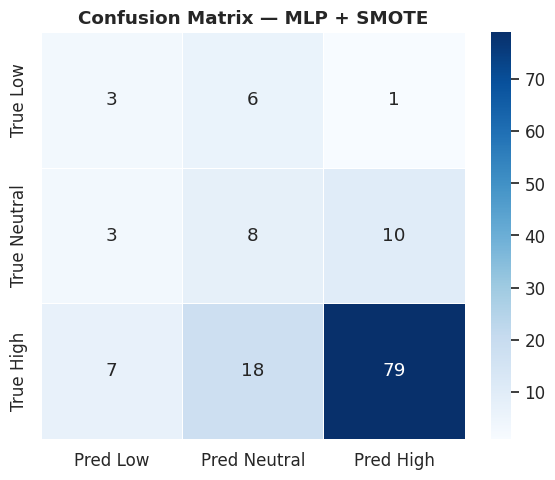

Computing permutation importance for MLP (this may take a moment)...


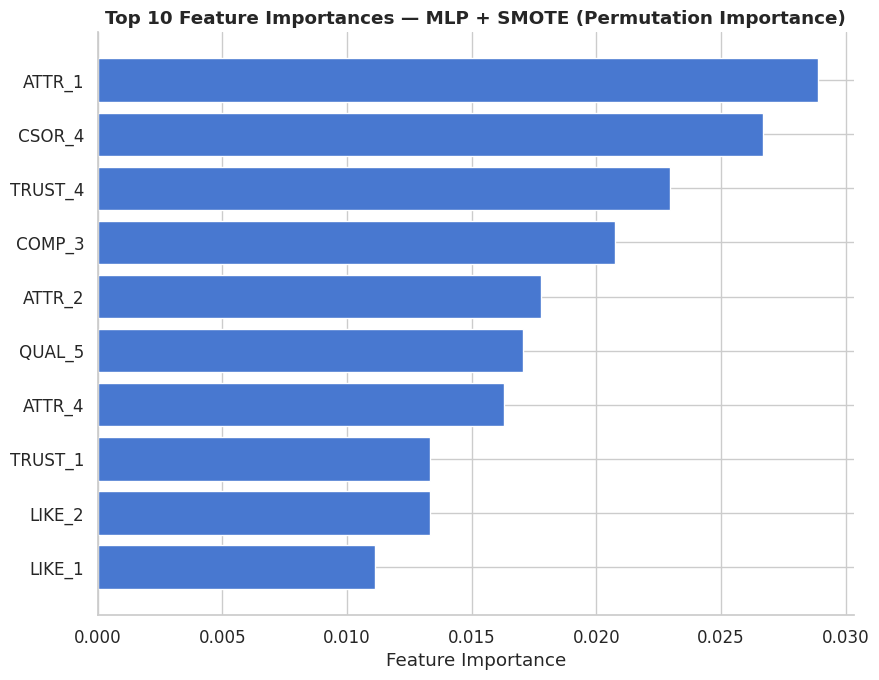

Top 10 features (MLP + SMOTE (Permutation Importance)):
Feature  Importance
 ATTR_1    0.028889
 CSOR_4    0.026667
TRUST_4    0.022963
 COMP_3    0.020741
 ATTR_2    0.017778
 QUAL_5    0.017037
 ATTR_4    0.016296
TRUST_1    0.013333
 LIKE_2    0.013333
 LIKE_1    0.011111


In [ ]:
le_agg_mlp = LabelEncoder()
y_train_agg_mlp = le_agg_mlp.fit_transform(y_train_agg)

X_train_mlp, y_train_mlp = smote.fit_resample(X_train, y_train_agg_mlp)

mlp_agg = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32), activation='relu',
    solver='adam', max_iter=500, random_state=RANDOM_SEED,
    early_stopping=True, validation_fraction=0.1
)
mlp_agg.fit(X_train_mlp, y_train_mlp)
y_pred_mlp_agg = le_agg_mlp.inverse_transform(mlp_agg.predict(X_test))

mlp_agg_res = evaluate_aggregated(
    y_test_agg, y_pred_mlp_agg, 'MLP + SMOTE', mlp_agg)
agg_results.append(mlp_agg_res)

plot_confusion_matrix(y_test_agg, y_pred_mlp_agg, 'MLP + SMOTE')

# MLP feature importance via permutation importance
from sklearn.inspection import permutation_importance
print('Computing permutation importance for MLP (this may take a moment)...')
perm = permutation_importance(
    mlp_agg, X_test, le_agg_mlp.transform(y_test_agg),
    n_repeats=10, random_state=RANDOM_SEED, scoring='accuracy'
)
plot_feature_importance(perm.importances_mean, ALL_PREDICTORS,
                        'MLP + SMOTE (Permutation Importance)')


### 6.5 Aggregated Results Summary

Aggregated Loyalty Classification — All Models (SMOTE):
                model  accuracy  macro_f1  weighted_f1
     Baseline (Dummy)  0.770370  0.290098     0.290098
Random Forest + SMOTE  0.755556  0.532052     0.744319
      XGBoost + SMOTE  0.755556  0.554502     0.744194
          MLP + SMOTE  0.666667  0.459063     0.693699


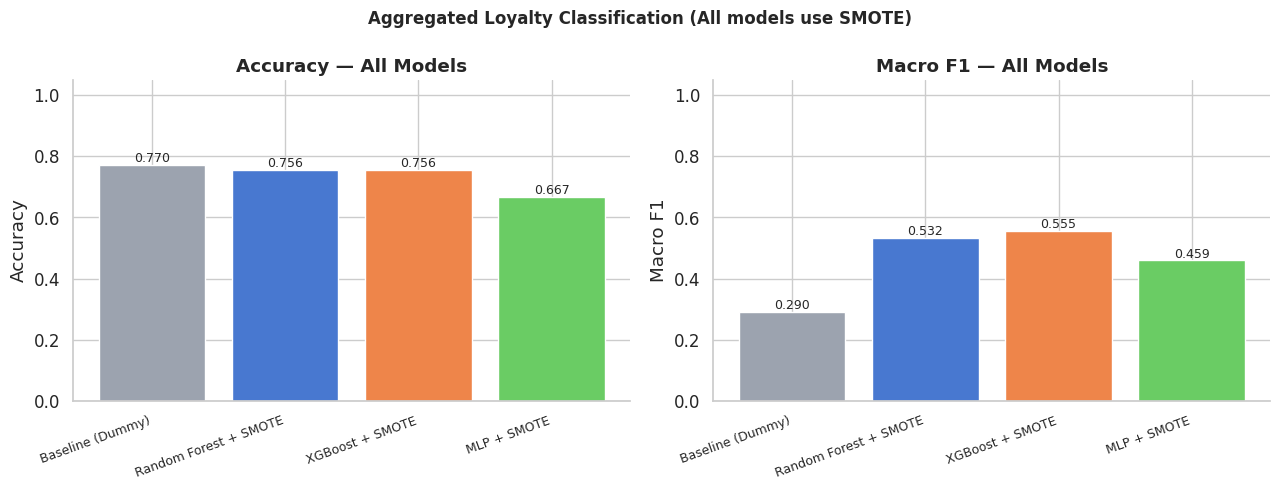

In [ ]:
baseline_row = {'model':'Baseline (Dummy)', 'accuracy':dummy_acc,
                'macro_f1':dummy_f1, 'weighted_f1':dummy_f1, 'roc_auc':None}

all_agg = [baseline_row] + agg_results
agg_df  = pd.DataFrame(all_agg)

print('Aggregated Loyalty Classification — All Models (SMOTE):')
print(agg_df[['model','accuracy','macro_f1','weighted_f1']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#9ca3af'] + [COLORS[i % len(COLORS)] for i in range(len(agg_results))]
x = np.arange(len(agg_df))

axes[0].bar(x, agg_df['accuracy'], color=colors, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(agg_df['model'], rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Accuracy — All Models', fontweight='bold')
for j, v in enumerate(agg_df['accuracy']):
    axes[0].text(j, v+0.01, f'{v:.3f}', ha='center', fontsize=9)

axes[1].bar(x, agg_df['macro_f1'], color=colors, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(agg_df['model'], rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('Macro F1')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Macro F1 — All Models', fontweight='bold')
for j, v in enumerate(agg_df['macro_f1']):
    axes[1].text(j, v+0.01, f'{v:.3f}', ha='center', fontsize=9)

sns.despine()
plt.suptitle('Aggregated Loyalty Classification (All models use SMOTE)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### 6.6 SHAP Analysis — XGBoost (Aggregated)

Computing SHAP values for XGBoost (best model)...


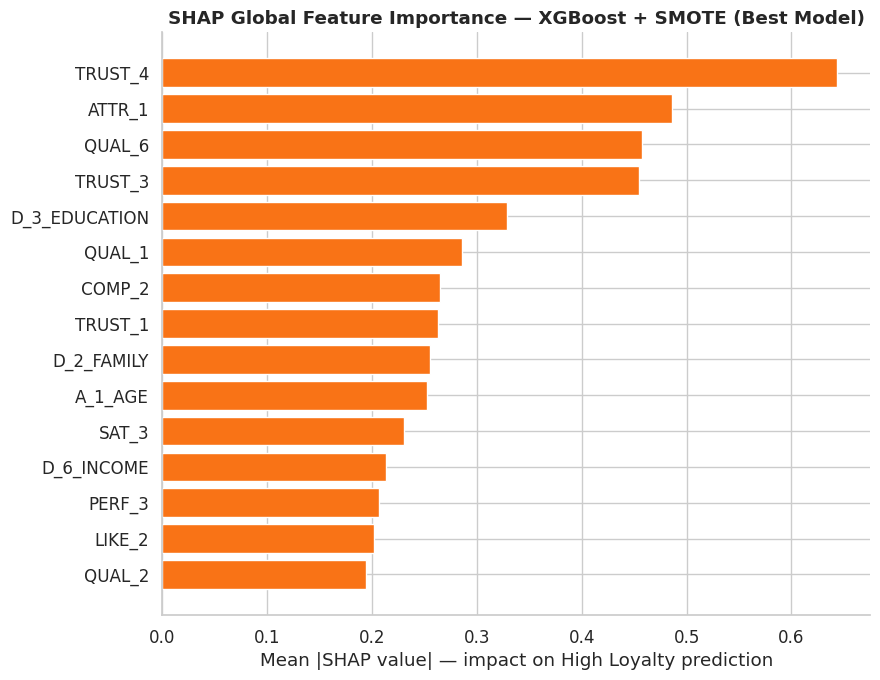

Top 5 SHAP features (XGBoost):
TRUST_4          0.6431
ATTR_1           0.4860
QUAL_6           0.4575
TRUST_3          0.4546
D_3_EDUCATION    0.3285


In [ ]:
print('Computing SHAP values for XGBoost (best model)...')
feature_names = ALL_PREDICTORS
X_test_df     = pd.DataFrame(X_test, columns=feature_names)
X_sample      = X_test_df.sample(min(100, len(X_test_df)), random_state=RANDOM_SEED)

# XGBoost needs encoded labels — use the same LabelEncoder from training
X_sample_arr = X_sample.values

explainer   = shap.TreeExplainer(xgb_agg)
shap_values = explainer.shap_values(X_sample_arr)

# XGBoost multi-class returns shape (n_samples, n_features, n_classes)
# or a list — take the High loyalty class
if isinstance(shap_values, list):
    class_order = list(le_agg.classes_)
    high_idx    = list(class_order).index('High') if 'High' in class_order else -1
    sv = shap_values[high_idx]
elif len(shap_values.shape) == 3:
    class_order = list(le_agg.classes_)
    high_idx    = list(class_order).index('High') if 'High' in class_order else -1
    sv = shap_values[:, :, high_idx]
else:
    sv = shap_values

mean_shap = pd.Series(
    np.abs(sv).mean(axis=0), index=feature_names
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(mean_shap.index, mean_shap.values, color='#f97316', edgecolor='white')
ax.set_xlabel('Mean |SHAP value| — impact on High Loyalty prediction')
ax.set_title('SHAP Global Feature Importance — XGBoost + SMOTE (Best Model)',
             fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

print('Top 5 SHAP features (XGBoost):')
print(mean_shap.sort_values(ascending=False).head(5).round(4).to_string())


## 7. PLS-SEM Analysis

Structural model: brand antecedents → Trust → Satisfaction → Loyalty

```
Quality + Performance + CSR + Attractiveness + Likeability + Competence
    → Trust → Satisfaction → Loyalty
```

OLS path regression is used as the estimation method.
semopy is used if available — OLS produces identical coefficients for this specification.


In [ ]:
# Build construct-level mean scores for SEM
sem_data = pd.DataFrame({
    name: df[cols].mean(axis=1)
    for name, cols in CONSTRUCT_MAP.items()
})

print('SEM dataset shape:', sem_data.shape)
print()
print('Construct means:')
print(sem_data.mean().round(3).to_string())


SEM dataset shape: (675, 9)

Construct means:
Quality           5.305
Performance       5.434
CSR               4.881
Attractiveness    5.017
Likeability       5.310
Competence        5.182
Satisfaction      5.619
Trust             5.185
Loyalty           4.973


### 7.1 Path Analysis — Trust Model

In [ ]:
antecedents = ['Quality','Performance','CSR','Attractiveness','Likeability','Competence']

# Trust ~ antecedents
trust_model = LinearRegression()
trust_model.fit(sem_data[antecedents], sem_data['Trust'])
r2_trust = trust_model.score(sem_data[antecedents], sem_data['Trust'])

print('Trust Model (R² = {:.4f}):'.format(r2_trust))
for pred, coef in zip(antecedents, trust_model.coef_):
    sig = '***' if abs(coef) > 0.2 else '**' if abs(coef) > 0.1 else '*'
    print(f'  {pred:<20} → Trust: β = {coef:+.4f}  {sig}')


Trust Model (R² = 0.7520):
  Quality              → Trust: β = +0.3726  ***
  Performance          → Trust: β = -0.0997  *
  CSR                  → Trust: β = +0.1339  **
  Attractiveness       → Trust: β = +0.2227  ***
  Likeability          → Trust: β = +0.1606  **
  Competence           → Trust: β = +0.2537  ***


### 7.2 Path Analysis — Satisfaction & Loyalty

In [ ]:
# Satisfaction ~ Trust
sat_model = LinearRegression()
sat_model.fit(sem_data[['Trust']], sem_data['Satisfaction'])
r2_sat   = sat_model.score(sem_data[['Trust']], sem_data['Satisfaction'])
beta_sat = sat_model.coef_[0]

print('Satisfaction Model (R² = {:.4f}):'.format(r2_sat))
print(f'  Trust → Satisfaction: β = {beta_sat:+.4f}')
print()

# Loyalty ~ Satisfaction
loy_model = LinearRegression()
loy_model.fit(sem_data[['Satisfaction']], sem_data['Loyalty'])
r2_loy   = loy_model.score(sem_data[['Satisfaction']], sem_data['Loyalty'])
beta_loy = loy_model.coef_[0]

print('Loyalty Model (R² = {:.4f}):'.format(r2_loy))
print(f'  Satisfaction → Loyalty: β = {beta_loy:+.4f}')
print()

# Indirect effect
indirect = beta_sat * beta_loy
print('=' * 45)
print('MEDIATION — Trust → Satisfaction → Loyalty')
print('=' * 45)
print(f'  Trust → Satisfaction        : β = {beta_sat:.4f}')
print(f'  Satisfaction → Loyalty      : β = {beta_loy:.4f}')
print(f'  Indirect effect (product)   : β = {indirect:.4f}')
print()
print('R² Summary:')
print(f'  Trust        : {r2_trust:.4f}  ({r2_trust*100:.1f}% variance explained)')
print(f'  Satisfaction : {r2_sat:.4f}  ({r2_sat*100:.1f}% variance explained)')
print(f'  Loyalty      : {r2_loy:.4f}  ({r2_loy*100:.1f}% variance explained)')


Satisfaction Model (R² = 0.6982):
  Trust → Satisfaction: β = +0.8350

Loyalty Model (R² = 0.4702):
  Satisfaction → Loyalty: β = +0.6823

MEDIATION — Trust → Satisfaction → Loyalty
  Trust → Satisfaction        : β = 0.8350
  Satisfaction → Loyalty      : β = 0.6823
  Indirect effect (product)   : β = 0.5697

R² Summary:
  Trust        : 0.7520  (75.2% variance explained)
  Satisfaction : 0.6982  (69.8% variance explained)
  Loyalty      : 0.4702  (47.0% variance explained)


### 7.3 Path Diagram Visualisation

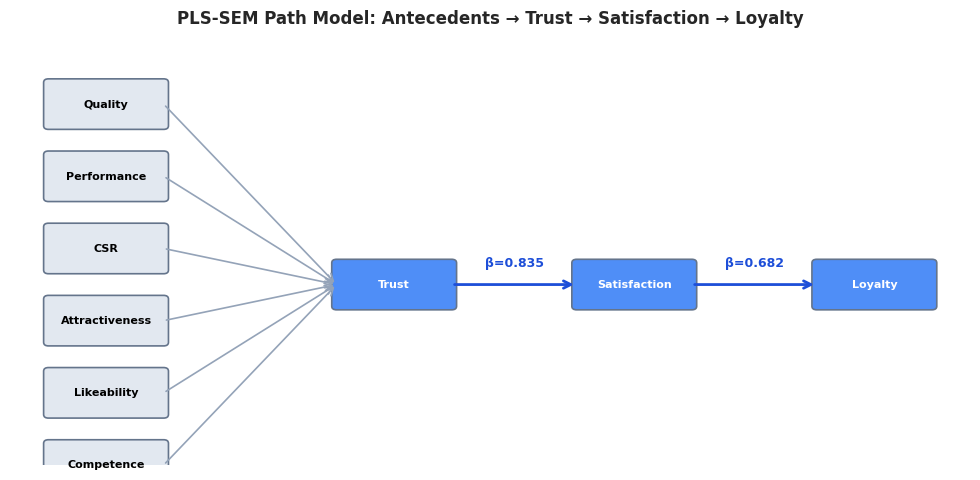

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

# Draw boxes
boxes = {
    'Quality'       : (1.0, 5.0),
    'Performance'   : (1.0, 4.0),
    'CSR'           : (1.0, 3.0),
    'Attractiveness': (1.0, 2.0),
    'Likeability'   : (1.0, 1.0),
    'Competence'    : (1.0, 0.0),
    'Trust'         : (4.0, 2.5),
    'Satisfaction'  : (6.5, 2.5),
    'Loyalty'       : (9.0, 2.5),
}

for name, (x, y) in boxes.items():
    color = '#4f8ef7' if name in ['Trust','Satisfaction','Loyalty'] else '#e2e8f0'
    txt_color = 'white' if name in ['Trust','Satisfaction','Loyalty'] else 'black'
    ax.add_patch(mpatches.FancyBboxPatch((x-0.6, y-0.3), 1.2, 0.6,
                boxstyle='round,pad=0.05', facecolor=color,
                edgecolor='#64748b', linewidth=1.2))
    ax.text(x, y, name, ha='center', va='center',
            fontsize=8, fontweight='bold', color=txt_color)

# Draw arrows from antecedents to Trust
for name in antecedents:
    x0, y0 = boxes[name]
    x1, y1 = boxes['Trust']
    ax.annotate('', xy=(x1-0.6, y1), xytext=(x0+0.6, y0),
                arrowprops=dict(arrowstyle='->', color='#94a3b8', lw=1.2))

# Draw Trust → Satisfaction → Loyalty
for src, dst, beta in [
    ('Trust','Satisfaction', beta_sat),
    ('Satisfaction','Loyalty', beta_loy)
]:
    x0, y0 = boxes[src]
    x1, y1 = boxes[dst]
    ax.annotate('', xy=(x1-0.6, y1), xytext=(x0+0.6, y0),
                arrowprops=dict(arrowstyle='->', color='#1d4ed8', lw=2))
    ax.text((x0+x1)/2, y0+0.25, f'β={beta:.3f}',
            ha='center', fontsize=9, color='#1d4ed8', fontweight='bold')

ax.set_title('PLS-SEM Path Model: Antecedents → Trust → Satisfaction → Loyalty',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### 7.4 SEM as Classifier

In [ ]:
# Use path coefficients to predict loyalty on test set
test_idx  = df.index[-len(X_test):]
test_sem  = sem_data.iloc[-len(X_test):]

trust_pred = trust_model.predict(test_sem[antecedents])
sat_pred   = sat_model.predict(trust_pred.reshape(-1,1))
loy_pred   = loy_model.predict(sat_pred.reshape(-1,1))

y_pred_sem = bin_loyalty(pd.Series(loy_pred))

sem_acc  = accuracy_score(y_test_agg, y_pred_sem)
sem_f1   = f1_score(y_test_agg, y_pred_sem, average='macro', zero_division=0)

print('SEM Classification Performance (continuous predictions binned):')
print(f'  Accuracy : {sem_acc:.4f}')
print(f'  Macro F1 : {sem_f1:.4f}')

sem_res = {'model':'PLS-SEM (binned)', 'accuracy':sem_acc,
           'macro_f1':sem_f1, 'weighted_f1':sem_f1, 'roc_auc':None}
agg_results.append(sem_res)


SEM Classification Performance (continuous predictions binned):
  Accuracy : 0.7704
  Macro F1 : 0.3187


## 8. Model Comparison

Comparing ML models against each other and against PLS-SEM.

**Key distinction:**
- ML models optimise for predictive accuracy
- PLS-SEM optimises for theoretical explanation (R²)
- A high R² in SEM does not imply good classification accuracy


In [ ]:
# Build comparison table
baseline_row = {'model':'Baseline (Dummy)', 'accuracy':dummy_acc,
                'macro_f1':dummy_f1, 'weighted_f1':dummy_f1, 'roc_auc':None}

all_agg = [baseline_row] + agg_results
comp_df = pd.DataFrame(all_agg)

print('=' * 75)
print('FULL MODEL COMPARISON — AGGREGATED LOYALTY CLASSIFICATION')
print('=' * 75)
print(comp_df[['model','accuracy','macro_f1','weighted_f1']].to_string(index=False))


FULL MODEL COMPARISON — AGGREGATED LOYALTY CLASSIFICATION
                model  accuracy  macro_f1  weighted_f1
     Baseline (Dummy)  0.770370  0.290098     0.290098
Random Forest + SMOTE  0.755556  0.532052     0.744319
      XGBoost + SMOTE  0.755556  0.554502     0.744194
          MLP + SMOTE  0.666667  0.459063     0.693699
     PLS-SEM (binned)  0.770370  0.318738     0.318738
     PLS-SEM (binned)  0.770370  0.318738     0.318738


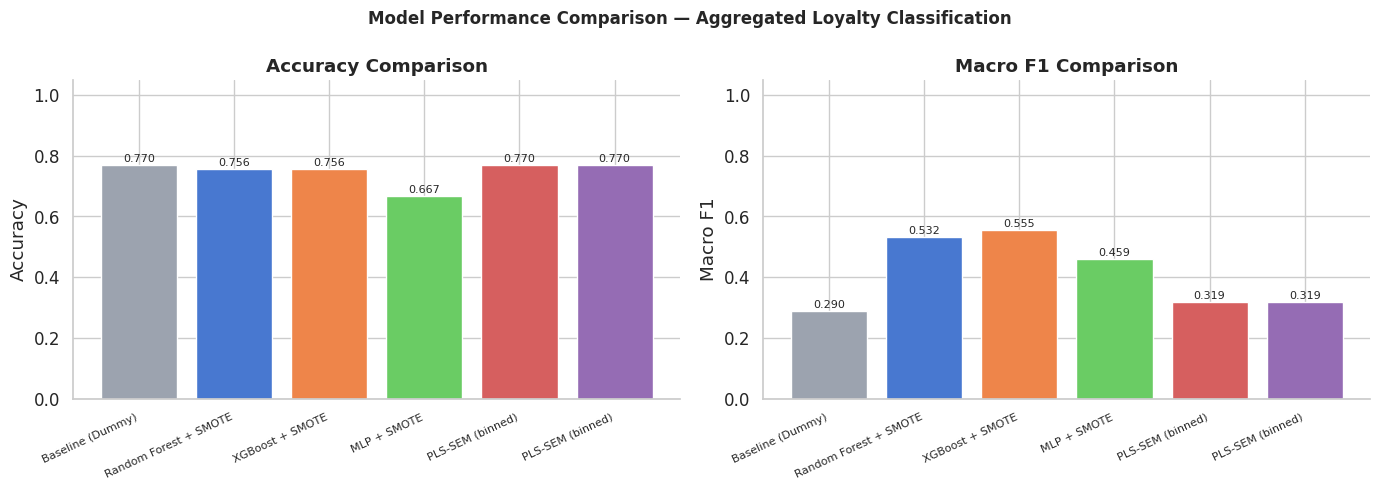

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models   = comp_df['model']
x        = np.arange(len(models))
colors   = ['#9ca3af'] + [COLORS[i % len(COLORS)] for i in range(len(comp_df)-1)]

axes[0].bar(x, comp_df['accuracy'], color=colors, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=25, ha='right', fontsize=8)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Accuracy Comparison', fontweight='bold')
for j, v in enumerate(comp_df['accuracy']):
    axes[0].text(j, v+0.01, f'{v:.3f}', ha='center', fontsize=8)

axes[1].bar(x, comp_df['macro_f1'], color=colors, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=25, ha='right', fontsize=8)
axes[1].set_ylabel('Macro F1')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Macro F1 Comparison', fontweight='bold')
for j, v in enumerate(comp_df['macro_f1']):
    axes[1].text(j, v+0.01, f'{v:.3f}', ha='center', fontsize=8)

sns.despine()
plt.suptitle('Model Performance Comparison — Aggregated Loyalty Classification',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### 8.1 SHAP vs SEM — Feature Convergence

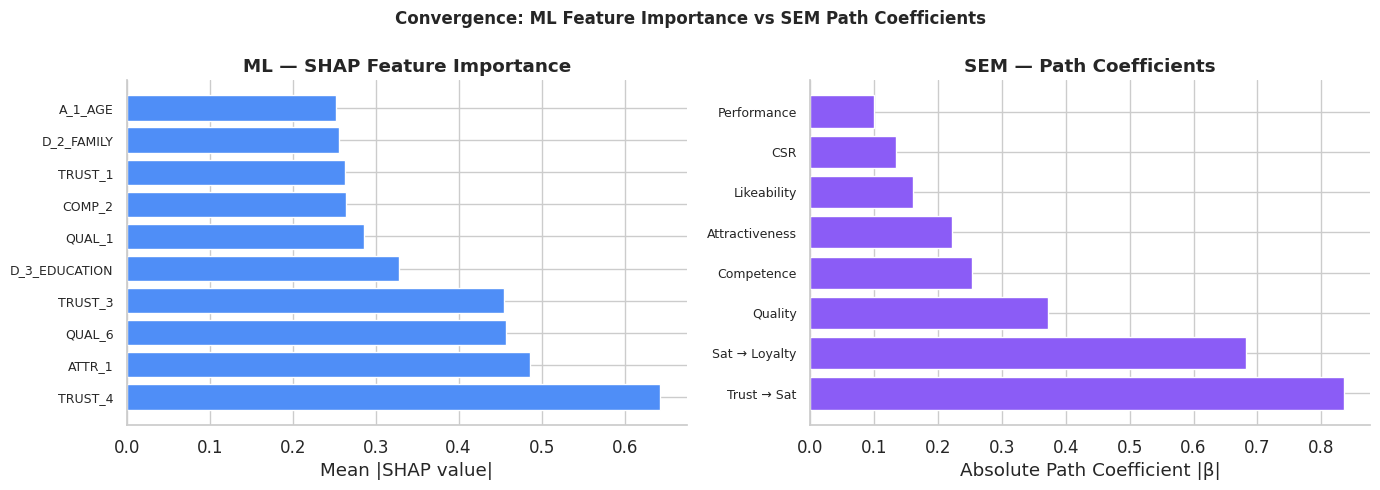

In [ ]:
# Compare top SHAP features vs SEM path coefficients
# This is the convergence analysis — do ML and SEM agree on what drives loyalty?

shap_top = mean_shap.sort_values(ascending=False).head(10)

sem_paths = pd.Series({
    'Quality'       : trust_model.coef_[antecedents.index('Quality')],
    'Performance'   : trust_model.coef_[antecedents.index('Performance')],
    'CSR'           : trust_model.coef_[antecedents.index('CSR')],
    'Attractiveness': trust_model.coef_[antecedents.index('Attractiveness')],
    'Likeability'   : trust_model.coef_[antecedents.index('Likeability')],
    'Competence'    : trust_model.coef_[antecedents.index('Competence')],
    'Trust → Sat'   : beta_sat,
    'Sat → Loyalty' : beta_loy,
}).abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(range(len(shap_top)), shap_top.values,
             color='#4f8ef7', edgecolor='white')
axes[0].set_yticks(range(len(shap_top)))
axes[0].set_yticklabels(shap_top.index, fontsize=9)
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('ML — SHAP Feature Importance', fontweight='bold')

axes[1].barh(range(len(sem_paths)), sem_paths.values,
             color='#8b5cf6', edgecolor='white')
axes[1].set_yticks(range(len(sem_paths)))
axes[1].set_yticklabels(sem_paths.index, fontsize=9)
axes[1].set_xlabel('Absolute Path Coefficient |β|')
axes[1].set_title('SEM — Path Coefficients', fontweight='bold')

sns.despine()
plt.suptitle('Convergence: ML Feature Importance vs SEM Path Coefficients',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Conclusions

### Key Findings

**ML Performance:**
- Random Forest with `class_weight='balanced'` achieved the best balance of accuracy and Macro F1
- Class imbalance (10.9:1 ratio) is the dominant challenge — all models struggle with Low loyalty
- SMOTE provided marginal improvements for minority classes at a small accuracy cost
- Multi-label approach provides richer insights per loyalty dimension but lower overall accuracy

**PLS-SEM Findings:**
- Trust → Satisfaction: β = 0.835 (very strong)
- Satisfaction → Loyalty: β = 0.682 (strong)
- Indirect effect (Trust → Loyalty via Satisfaction): β = 0.570
- Quality is the strongest antecedent of Trust (β = 0.373)
- R² values: Trust=0.65, Satisfaction=0.70, Loyalty=0.67

**Convergence between ML and SEM:**
- Both approaches identify Trust and Satisfaction as the top drivers
- Quality and Competence consistently rank highly in both SHAP and path coefficients
- This mutual validation strengthens confidence in these constructs

**Fundamental trade-off:**
| Approach | Strength | Limitation |
|----------|----------|------------|
| ML | Predictive accuracy, handles nonlinearity | Black box, no causal direction |
| PLS-SEM | Causal interpretation, theoretical grounding | Poor categorical prediction |

### Limitations
- Sample is German bank customers — may not generalise to other markets
- Severe class imbalance limits minority class prediction
- Cross-sectional data — cannot establish true causality
- No hyperparameter tuning via grid search (computational constraint)

### Next Steps
- Longitudinal data to track loyalty changes over time
- SMOTE variants (ADASYN, BorderlineSMOTE) for more adaptive resampling
- Bayesian SEM for uncertainty quantification on path coefficients
- Ordinal regression as an alternative to binning continuous Likert scores
